# Baseline CNN Model (Baseline Model)

For our first CNN model, we will start with a network containing four convolutional layers, each followed by 2×2 max pooling. After that, the model will pass through two fully connected layers before providing the final prediction. The number of channels is kept relatively low in order to reduce computational cost. In `src/models.py`, there is a breakdown of the number of channels and image size through all steps of the model. Finally, this model will be referred to as the **Baseline Model** from now on, and it will serve as a simple yet important starting point for the following models.

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform = get_transform()
dataset = get_data(transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
print(f"Classes: {dataset.classes}")

Classes: ['1-Cardboard', '2-Food Organics', '3-Glass', '4-Metal', '5-Miscellaneous Trash', '6-Paper', '7-Plastic', '8-Textile Trash', '9-Vegetation']


In [6]:
train_data, val_data, test_data = get_datasets(transform, transform)

In [7]:
# example of a single image from the training set

image, label = train_data[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
2


In [8]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [9]:
from src.models import BaselineConvolutionalNetwork

The model was trained using the SGD optimizer with a learning rate of 0.001 and momentum of 0.9. Cross-Entropy Loss was used as the loss function, and the model was trained for 50 epochs.

In [10]:
baseline_model = BaselineConvolutionalNetwork()
baseline_model.load_state_dict(torch.load('models/01_baseline_sgd_momentum50.pth'))

<All keys matched successfully>

In [11]:
baseline_model.to(device)

BaselineConvolutionalNetwork(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6912, out_features=90, bias=True)
  (fc2): Linear(in_features=90, out_features=9, bias=True)
)

## Evaluating Model

In [12]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [13]:
loss, accuracy, all_labels, all_predictions = evaluate_model(baseline_model, val_loader)

In [14]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 2.8811
Accuracy: 55.33%


Given the validation loss of 2.8811 and accuracy of 55.33%, we can see that the model is likely overfitting to the training data. This is expected for now because our model is relatively simple and does not yet use any data augmentation or other techniques to improve generalization. One possible cause, for example, is that the model is assuming objects only exist in the exact orientation shown during training, or in a specific position within the image. This could partially explain the poor generalization to the validation data.

### - Confusion Matrix

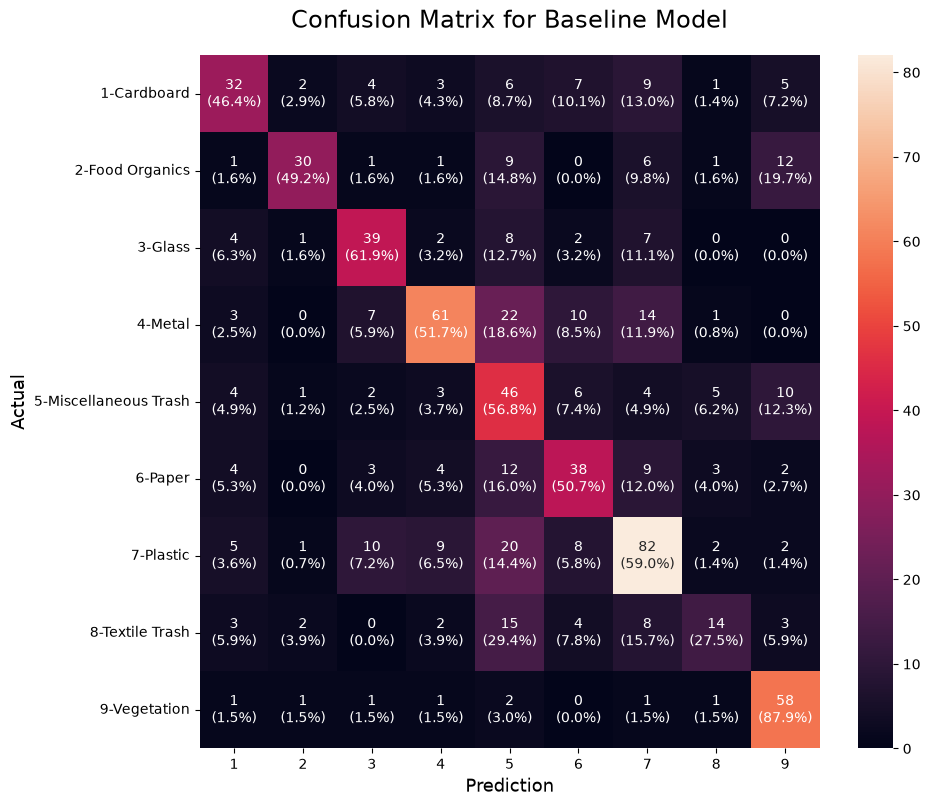

In [15]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for Baseline Model")

**Confusion Matrix Insights:**

. Most classes got an accuracy of around 45–60%.

. The worst class was Textile Trash, with only 27.5% accuracy. We can see that the model classified 29.4% of true Textile Trash as Miscellaneous Trash, probably because of the high variability of items within both categories. Also, this may be one of the reasons why the model predicted many objects as Miscellaneous Trash.

. The biggest surprise was the Vegetation class, scoring an accuracy of 87.9%, much higher than any other class.

### - Inspecting misclassified images

Found 22 4-Metal → 5-Miscellaneous Trash


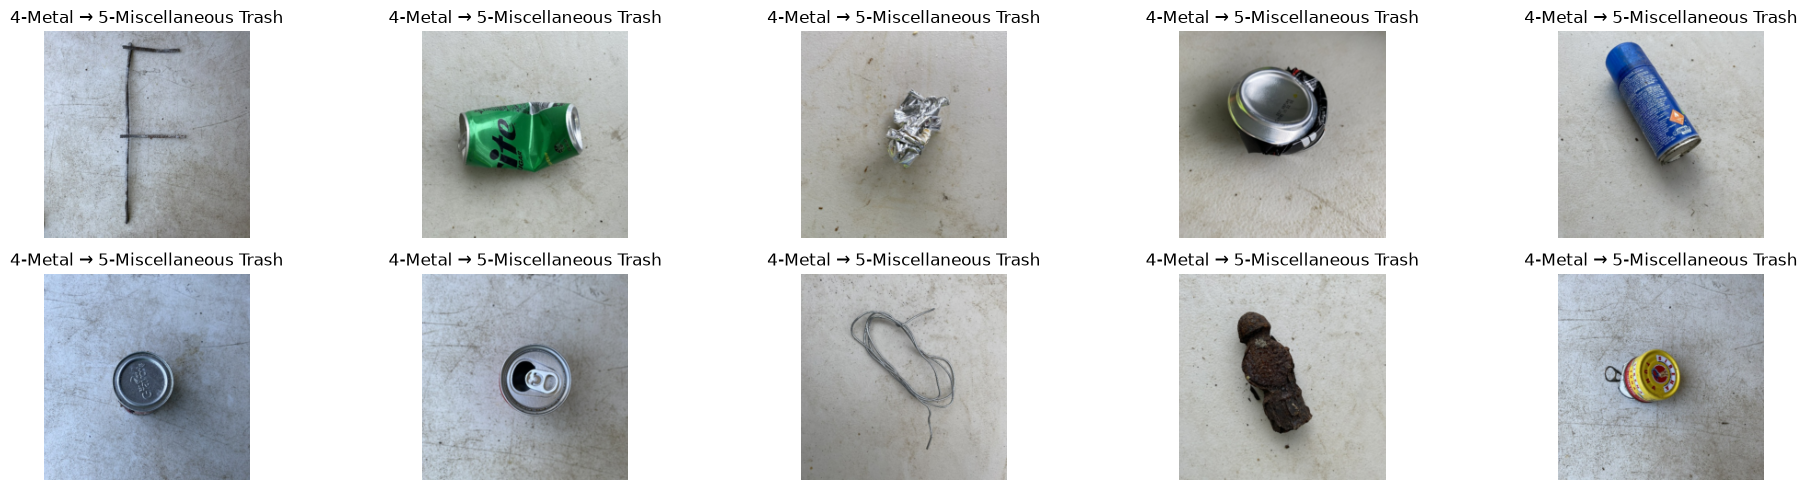

In [16]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "5-Miscellaneous Trash") # 22 errors

Found 20 7-Plastic → 5-Miscellaneous Trash


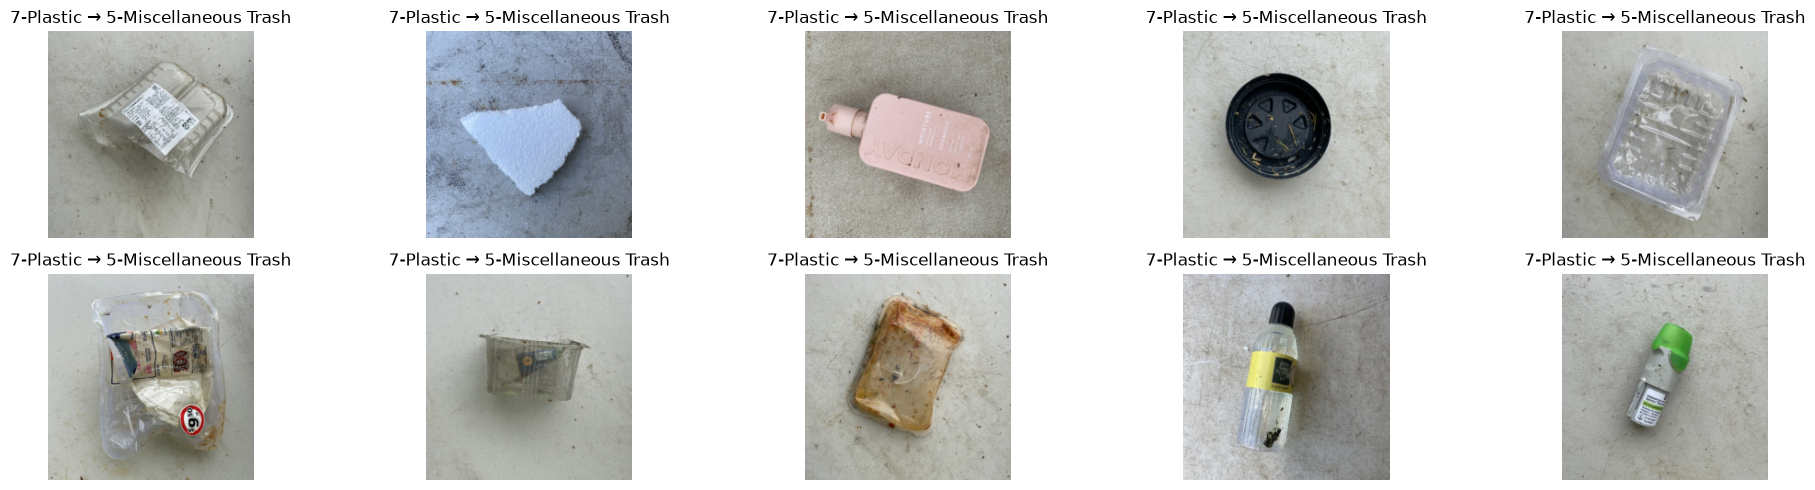

In [17]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "7-Plastic", "5-Miscellaneous Trash") # 20 errors

Found 15 8-Textile Trash → 5-Miscellaneous Trash


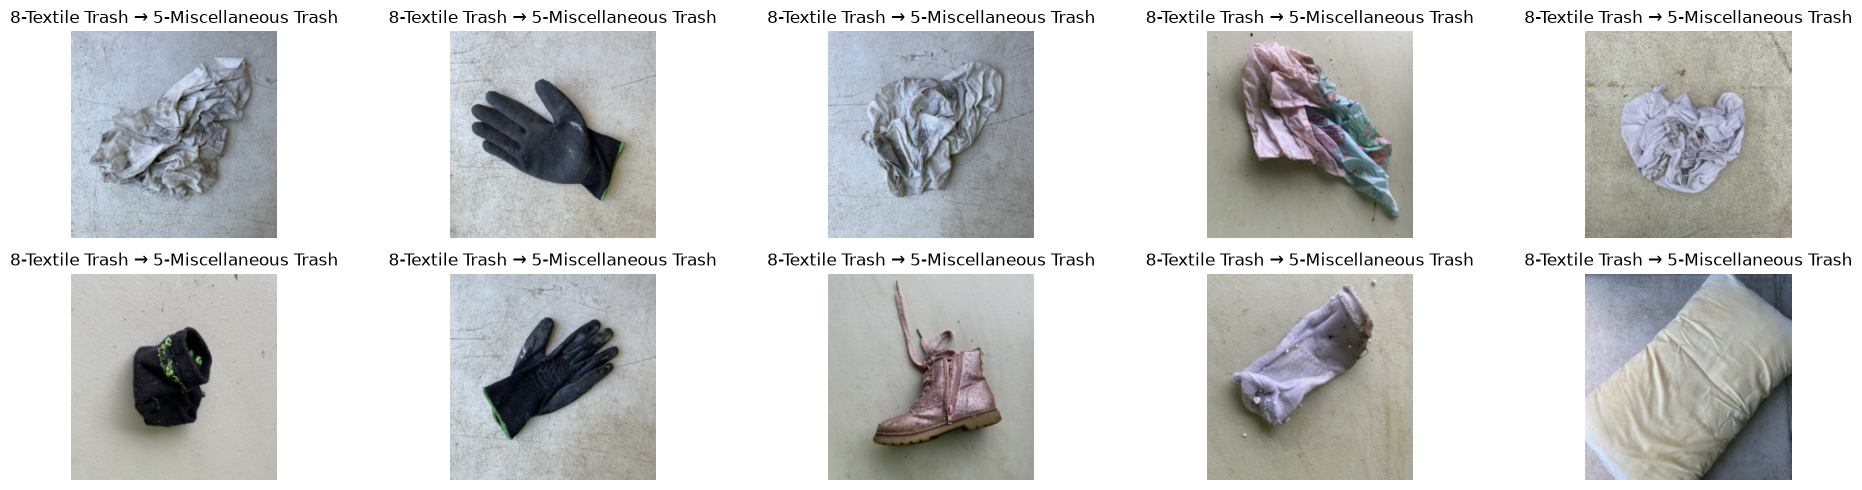

In [18]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "8-Textile Trash", "5-Miscellaneous Trash") # 15 errors

Found 14 4-Metal → 7-Plastic


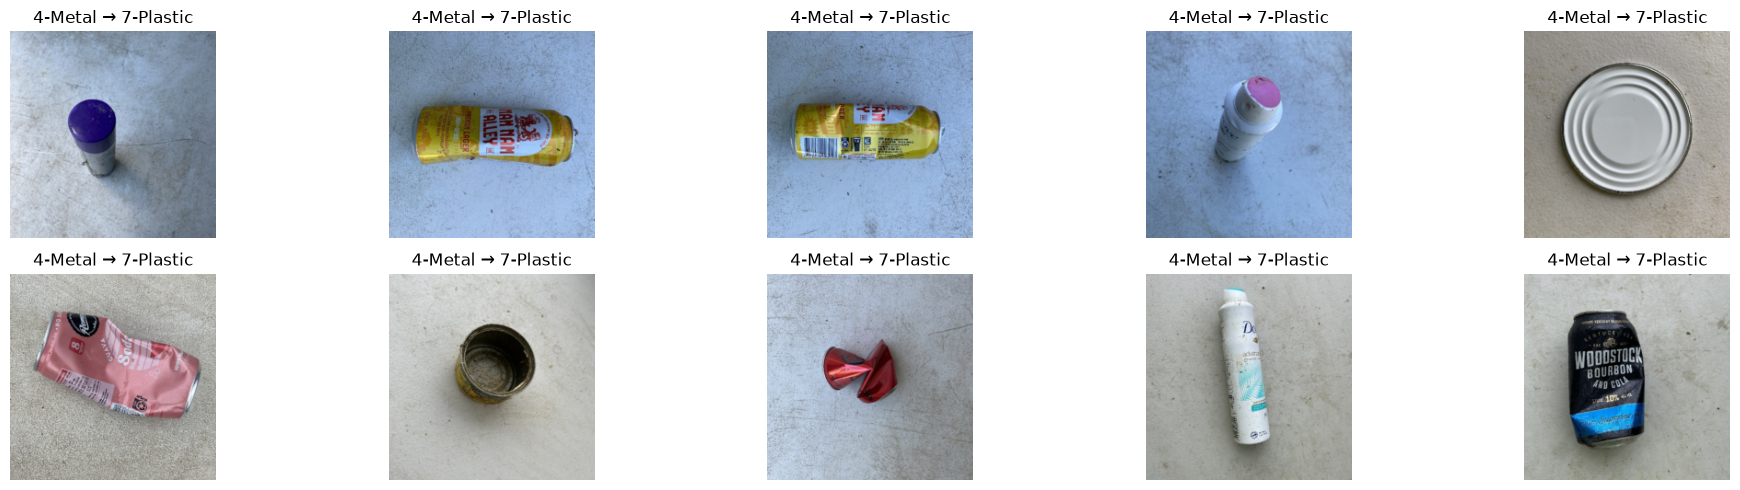

In [19]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "7-Plastic") # 14 erros

**Misclassified Images Insights:**  

. The Miscellaneous Trash class contains sparse and ambiguous examples, which is probably causing the model to classify conflicting images into this category.

. The model misclassifies some visually clear examples, such as a metal can or a plastic container being classified as Miscellaneous Trash.